# SmallWorld Brian2 

1. **Imports** 
2. **Config** 
3. **Functions** : `build_network`, `build_inputs`, `run_simulation`, `compute_metrics`, `plot_*` 
4. **Run** 
5. **Parameter sweep**

In [1]:
from brian2 import prefs
prefs.codegen.target = "cython"

INFO       Cache size for target 'cython': 1212 MB.
You can call clear_cache('cython') to delete all files from the cache or manually delete files in the 'C:\Users\vicki\.cython\brian_extensions' directory. [brian2]


In [2]:
# import os
# import subprocess

# # Injection des chemins vers les outils MSVC 64-bits de Visual Studio Build Tools
# msvc_bin = r"C:\Program Files (x86)\Microsoft Visual Studio\18\BuildTools\VC\Tools\MSVC\14.51.36231\bin\HostX64\x64"
# os.environ["PATH"] = msvc_bin + os.pathsep + os.environ["PATH"]

# from brian2 import prefs
# prefs.codegen.target = "cython"

## Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from brian2 import *
import seaborn as sns

## Config

In [ ]:
# ================================================
# CONFIG — To modify the parameters
# ================================================
config = {
    # --- Network (Watts-Strogatz) ---
    "N" : 100,      # number of neurons
    "k" : 10,       # neighbors in the ring lattice
    "beta" : 0.25,     # rewiring probability
    "seed_graph" : 123,      # random seed for the graph
    "seed_weights" : 42,       # random seed for the weights
    "W_scale" : 100.0,    # scale factor for synaptic weights (global gain)
    "inhib_threshold": 10,       # threshold for inhibitory neurons (top % of weights)

    # --- Neurons (LIF) ---
    "gL" : 0.5,    # leak conductance (/ms)
    "EL" : -50.0,  # resting potential (mV)
    "Vthreshold": 30.0,   # spike threshold (mV)
    "Vreset" : -60.0,  # reset potential (mV)
    "sigma" : 10.0,   # noise amplitude (sigma^2 in mV^2/ms)
    "delta_spike": 1.0,   # synaptic spike amplitude

    # --- Simulation ---
    "duration": 200,   # total duration (ms)
    "dt" : 0.01,  # time step (ms)

    # --- Inputs ---
    "I_static_scale" : 10.0,   # amplitude of the constant input 
    "I_oscillatory_scale" : 6.0,    # base amplitude of the oscillatory input 
    "I_bump_amplitude" : 30.0,   # amplitude of the bump input 
    "I_bump_width_factor" : 10.0,   # factor of bump width 
    "I_oscillatory_frequency" : 2.0,    # frequency of oscillation (cycles / 200 ms)
    "I_phase_switch_time" : 100.0,  # time of phase switch (ms)
}

## Functions

In [ ]:
# ================================================
# FUNCTION : build_network(config)
# ================================================
def build_network(config):
    """
    Build the network Watts-Strogatz and the synaptic weights matrix

    Parameters
    ----------
    config : dict

    Returns
    --------
    A : np.ndarray (N×N) — adjacency matrix => connectivity (0/1)
    M : np.ndarray (N×N) — modulation matrix => inhibition/excitation (lateral inhibition)
    Wsyn_matrix : np.ndarray (N×N) — final synaptic weights matrix
    G_nx : networkx.Graph — the underlying Watts-Strogatz graph (for topology metrics)
    """

    N = config["N"]
    beta = config["beta"]
    k = config["k"]
    inhib_threshold = config["inhib_threshold"]
    

    # Watts-Strogatz Graph
    G_nx = nx.watts_strogatz_graph(n=N, k=k, p=beta, seed=config["seed_graph"])
    A = nx.to_numpy_array(G_nx)

    # Synaptic strength matrix M  (convention [post, pre], similar than in Julia)
    np.random.seed(config["seed_weights"])
    M = np.ones((N, N))
    for idx_post in range(N): # row = post
        for idx_pre in range(N): # column = pre
            if (abs(idx_post - idx_pre) > inhib_threshold
                    and abs(idx_post - idx_pre) < (N - inhib_threshold)
                    and np.random.rand() > (beta / 2)):
                M[idx_post, idx_pre] = -1.0                             # between 100% and 50% of the long distance are inhibitory

    # Final synaptic weights matrix
    Wsyn_matrix = config["W_scale"] * (A @ M)

    return A, M, Wsyn_matrix, G_nx

In [ ]:
# ================================================
# FUNCTION : build_inputs(config)
# ================================================
def build_inputs(config):
    """
    Build the TimedArray Brian2 for the inputs (constant and oscillatory)

    Parameters
    ----------
    config : dict

    Returns
    --------
    I_constant_input : TimedArray — constant input current
    I_oscillatory_input : TimedArray — oscillatory spatiotemporal input
    I_oscillatory_matrix : np.ndarray (time_steps × N) — raw values
    t_vec : np.ndarray (time_steps,)    — time vector (Brian2 units)
    time_steps  : int
    """

    N = config["N"]
    beta = config["beta"]
    duration = config["duration"] * ms
    dt = config["dt"] * ms

    time_steps = int(duration / dt) + 1
    t_vec = np.arange(time_steps) * dt

    # -----------------------------------------------
    # Constant input current  I(t) = I_static_scale * beta
    # -----------------------------------------------
    I_static_profile = (config["I_static_scale"] * np.ones(N) * beta + 0.0) * (mV / ms)
    I_matrix = np.tile(I_static_profile, (time_steps, 1))
    I_constant_input = TimedArray(I_matrix, dt=dt)

    # -----------------------------------------------
    # Spatiotemporal oscillatory input
    # -----------------------------------------------
    I_oscillatory_matrix = np.zeros((time_steps, N))

    for idx_t, t_val in enumerate(t_vec):
        phase_shift = np.pi / 2.0 if t_val > config["I_phase_switch_time"] * ms else 0.0
        oscillatory_shift = (N / 2.0) * np.sin(config["I_oscillatory_frequency"] * 2.0 * np.pi * (t_val / ms) / 200.0 + phase_shift)
        x_coord = -N / 2.0 + oscillatory_shift + (np.arange(N) * (N / (N - 1.0)))
        bump = config["I_bump_amplitude"] * np.exp(-(x_coord**2) / (N / config["I_bump_width_factor"])**2) * np.exp(-((t_val / ms) - 100.0) / 1e6)
        I_oscillatory_matrix[idx_t, :] = config["I_oscillatory_scale"] * beta + bump

    I_oscillatory_input = TimedArray(I_oscillatory_matrix * (mV / ms), dt=dt)

    return I_constant_input, I_oscillatory_input, I_oscillatory_matrix, t_vec, time_steps

In [ ]:
# ================================================
# FUNCTION : run_simulation(config, verbose=True)
# ================================================
def run_simulation(config, verbose=True):
    """
    Run the complete Brian2 simulation (network + inputs + neurons, synapses, monitors)

    Parameters
    ----------
    config  : dict
    verbose : bool — shows progress if True

    Returns
    --------
    spike_mon : SpikeMonitor
    state_mon : StateMonitor (V, S, Z)
    I_oscillatory_matrix : np.ndarray — input oscillatory raw values (time_steps × N)
    t_vec : np.ndarray — time vector (Brian2 units)
    time_steps : int
    A : np.ndarray — adjacency matrix (connectivity)
    M : np.ndarray — modulation matrix (inhibition/excitation)
    Wsyn_matrix : np.ndarray — final synaptic weights matrix
    G_nx : networkx.Graph — underlying Watts-Strogatz graph
    """

    start_scope()  # Reset Brian2 state (essential for multiple runs)

    N = config["N"]

    # ---- Network ----
    A, M, Wsyn_matrix, G_nx = build_network(config)

    # ---- Inputs ----
    I_constant_input, I_oscillatory_input, I_oscillatory_matrix, t_vec, time_steps = build_inputs(config)

    # ---- Simulation parameters ----
    duration = config["duration"] * ms
    defaultclock.dt = config["dt"] * ms

    # Model parameters (accessible in the Brian2 equations via the local namespace)
    gL_val = config["gL"] / ms
    sigma = np.sqrt(config["sigma"]) * (mV / sqrt(ms))
    Vthreshold = config["Vthreshold"] * mV
    Vreset = config["Vreset"] * mV
    EL = config["EL"] * mV
    delta_spike = config["delta_spike"]

    # ================================================
    # LIF EQUATIONS (membrane potential V + adaptation variable Z + synaptic current S)
    # xi = white gaussian noise from Brian2
    # ================================================
    eqs = '''
        dV/dt = -gL * Z * (V - EL) + I_oscillatory_input(t, i) + (S * mV / ms) + sigma*xi : volt
        dS/dt = -S / ms : 1
        dZ/dt = -0.01 * Z / ms : 1
        gL : 1/second
    '''

    # ---- Group of neurons ----
    neurons = NeuronGroup(
        N,
        model=eqs,
        threshold='V > Vthreshold',
        reset='V = Vreset; Z += 0.05 * delta_spike',
        method='euler'
    )

    # Initialize specific parameters per neuron
    neurons.gL = gL_val

    # Initial conditions (similar to Julia notebook)
    neurons.V = (30.0 * np.random.randn(N)) * mV
    neurons.Z = np.random.rand(N)
    neurons.S = 100.0 * np.random.rand(N)

    # ---- Synapses ----
    # NOTE (fix): using 'S = clip(S + delta_spike*w, 0, 100)' is order-dependent when several synapses fire onto the same neuron in the same timestep (Brian2 warning). 
    # We instead accumulate commutatively with '+=', then clip S exactly once per timestep (after all synaptic events of that step, via run_regularly).
    # This keeps the saturation behaviour of the original model while removing the order-dependency.

    synapses = Synapses(
        neurons, neurons,
        model='w : 1',
        #on_pre='S = clip(S + delta_spike * w, 0, 100)'
        on_pre='S += delta_spike * w'
    )


    targets, sources = np.nonzero(Wsyn_matrix)
    synapses.connect(i=sources, j=targets)
    synapses.w = Wsyn_matrix[targets, sources]

    neurons.run_regularly('S = clip(S, 0, 100)', when='resets', order=1)

    # ---- Monitors ----
    spike_mon = SpikeMonitor(neurons)
    state_mon = StateMonitor(neurons, ['V', 'S', 'Z'], record=True)

    # ---- Run ----
    run(duration, report='text' if verbose else None)

    return spike_mon, state_mon, I_oscillatory_matrix, t_vec, time_steps, A, M, Wsyn_matrix, G_nx

In [ ]:
# ================================================
# FUNCTIONS FOR VISUALIZATION
# ================================================

def plot_connectivity(A, M, config):
    """Display the connectivity matrix"""
    plt.figure(figsize=(10, 5))
    plt.imshow( A * M, aspect='auto', cmap='bwr', vmin=-1, vmax=1, origin='lower')
    plt.colorbar(ticks=[-1, 0, 1], label="Edge weight")
    plt.xlabel("Presynaptic neuron index")
    plt.ylabel("Postsynaptic neuron index")
    plt.title(f"Connectivity matrix of the network (beta={config['beta']})")
    plt.show()


def plot_oscillatory_input(I_oscillatory_matrix, t_vec, config):
    """Display the spatiotemporal view of the oscillatory input"""
    t_vec_ms = t_vec / ms
    plt.figure(figsize=(10, 5))
    plt.imshow(I_oscillatory_matrix.T, aspect='auto', origin='lower',
               extent=[t_vec_ms[0], t_vec_ms[-1], 0, config["N"]], cmap='viridis')
    plt.colorbar(label="Input Current amplitude")
    plt.xlabel("Time (ms)")
    plt.ylabel("Neuron Index (Space)")
    plt.title("Spatiotemporal view: Movement of the activation bump across the network")
    plt.show()


def plot_raster(spike_mon, t_vec, config):
    """Display the raster plot + the reference oscillatory wave"""
    N = config["N"]
    time_steps = len(t_vec)

    plt.figure(figsize=(12, 6))

    # spikes
    spikes_t = spike_mon.t / ms
    spikes_i = spike_mon.i
    plt.scatter(spikes_t, spikes_i, marker='|', color='black', s=10, linewidths=0.5)

    # oscillatory input
    tvec = np.arange(time_steps) * (config["dt"])  # in ms
    phase_shift = np.where(tvec > 100.0, np.pi / 2.0, 0.0)
    blue_wave = (
        -np.sin(config["I_oscillatory_frequency"] * 2.0 * np.pi * tvec / 200.0 + phase_shift) + 1.0
    ) * N / 2.0
    plt.scatter(tvec, blue_wave, s=2, color='blue', edgecolors='none')

    plt.xlabel("time")
    plt.ylabel("Neuron index")
    plt.title(f"Raster Plot | beta = {config.get("beta", "N/A")}, k = {config.get("k", "N/A")}")
    plt.show()


def plot_adaptation(state_mon, config):
    """Display the dynamics of the adaptation variable Z"""
    plot_step_z = 100
    time_ms = state_mon.t / ms
    plt.figure(figsize=(12, 6))
    for i in range(config["N"]):
        plt.plot(time_ms[10::plot_step_z], state_mon.Z[i][10::plot_step_z])
    plt.xlabel("Time (ms)")
    plt.ylabel("Z (Adaptation)")
    plt.title("Dynamics of the adaptation variable Z for each neuron")
    plt.show()


def plot_synaptic(state_mon, config):
    """Display the dynamics of the synaptic current S (initial phase)"""
    time_ms = state_mon.t / ms
    plt.figure(figsize=(12, 6))
    for i in range(config["N"]):
        plt.plot(time_ms[10:1000:1], state_mon.S[i][10:1000:1], linewidth=1.5)
    plt.xlabel("Time (ms)")
    plt.ylabel("S (Synaptic Current)")
    plt.title("Dynamics of the synaptic current S for each neuron (Initial phase)")
    plt.show()


def plot_voltage(state_mon, config):
    """Display the dynamics of the membrane potential V for a few neurons"""
    time_ms = state_mon.t / ms
    plt.figure(figsize=(12, 6))
    for i in [1, 2]:   # neurons 2 and 3 (indexation 0-based Python)
        plt.plot(time_ms[10::1], state_mon.V[i][10::1] / mV, linewidth=1.5)
    plt.xlabel("Time (ms)")
    plt.ylabel("V (mV)")
    plt.title("Membrane potential dynamics for a few neurons")
    plt.show()


def plot_results(spike_mon, state_mon, A, M, I_oscillatory_matrix, t_vec, config):
    """Launch the entire set of plots."""
    plot_connectivity(A, M, config)
    plot_oscillatory_input(I_oscillatory_matrix, t_vec, config)
    plot_raster(spike_mon, t_vec, config)
    plot_adaptation(state_mon, config)
    plot_synaptic(state_mon, config)
    plot_voltage(state_mon, config)

### Metrics

In [ ]:
# ================================================
# FUNCTION : compute_metrics(G_nx, config)
# ================================================
def compute_metrics(spike_mon, config):
    """
    Compute the key metrics after simulation

    Parameters
    ----------
    spike_mon : SpikeMonitor
    config : dict

    Returns
    --------
    dict with :
      - active_neurons    
      - firing_rates (Hz)
      - mean_firing_rate (Hz)
      - std_firing_rate (Hz)
      - synchrony_index  
    """

    N = config["N"]
    duration_s = config["duration"] / 1000.0   # ms → seconds

    spike_trains = spike_mon.spike_trains()
    firing_rates = [len(spike_trains[i]) / duration_s for i in range(N)]

    # Synchrony : variability of the mean binned activity (10 ms)
    bin_size = 10  # ms
    bins = np.arange(0, config["duration"] + bin_size, bin_size)
    counts = np.array([np.histogram(np.array(spike_trains[i]) / ms, bins)[0] for i in range(N)])
    mean_activity = counts.mean(axis=0)
    synchrony = mean_activity.std() / (mean_activity.mean() + 1e-9)

    return {
        "active_neurons" : int(np.sum(np.array(firing_rates) > 0)),
        "firing_rates" : firing_rates,
        "mean_firing_rate" : np.mean(firing_rates),
        "std_firing_rate" : np.std(firing_rates),
        "synchrony_index" : synchrony,
    }

In [ ]:
# ================================================
# FUNCTION : compute_network_metrics(G_nx, config)
# ================================================
def compute_network_metrics(G_nx, config):
    """
    Compute topological (small-world) metrics of the Watts-Strogatz graph.

    C : average clustering coefficient (local density)
    L : characteristic path length (global integration)
    omega : omega ≈ 0 => small-world 
            omega→ -1 => lattice (clustering dominates)
            omega → +1 +> random(Shortest path dominates; clustering fails)
            

    Omega compares network clustering to an equivalent lattice network,
    and path length to an equivalent random network. omega ∈ [-1, 1]

    Parameters
    ----------
    G_nx : networkx.Graph — Watts-Strogatz graph (from build_network)
    config : dict

    Returns
    -------
    dict with keys: C, L, omega
    """
    N = config["N"]
    C = nx.average_clustering(G_nx)
    try:
        L = nx.average_shortest_path_length(G_nx)
    except nx.NetworkXError:
        L = np.nan
    try:
        omega = nx.omega(G_nx, niter=1, nrand=5, seed=config["seed_graph"]) #niter/nrand to increase for greater accuracy, but that becomes computationally expensive
    except (nx.NetworkXError, ZeroDivisionError):
        omega = np.nan

    return {"C": C, "L": L, "omega": omega}


In [ ]:
# ================================================
# FUNCTION : compute_isi_cv(spike_mon, config)
# ================================================
def compute_isi_cv(spike_mon, config):
    """
        Compute the coefficient of variation (CV) of the inter-spike intervals (ISI) 
        for each neuron, then average across the population (→ firing regularity).
    
        CV ~ 1   -> Poisson-like (irregular, random) firing
        CV < 1   -> regular firing
        CV > 1   -> bursty firing

        CV2 is robust against non-stationarity (slow changes in firing rate)
                
        CV2 ~ 0 -> very regular locally
        CV2 ~ 1 -> highly irregular/bursty locally
    
        Parameters
        ----------
        spike_mon : SpikeMonitor
        config    : dict
    
        Returns
        -------
        isi_cv_mean : float — mean CV across neurons that spiked more than twice
        isi_cv_std  : float — std of the CV across those neurons
        """
    
    N = config["N"]
    spike_trains = spike_mon.spike_trains()
    cvs = []
    cv2s = []
    
    for i in range(N):
        spikes = np.array(spike_trains[i] / ms)
        if len(spikes) > 2:
            isi = np.diff(spikes)
            if isi.mean() > 0:
                # 1. CV (global)
                cvs.append(isi.std() / isi.mean())

                # 2. CV2 (local) - standard formula from Holt et al. (1996)
                if len(isi) > 1:
                    # Formula : 2 * |ISI_{i+1} - ISI_i| / (ISI_{i+1} + ISI_i)
                    numerators = 2.0 * np.abs(np.diff(isi))
                    denominators = isi[:-1] + isi[1:]
                    # Avoid division by zero if two consecutive spikes have a zero ISI (very rare)
                    valid = denominators > 0
                    if np.any(valid):
                        cv2_i = np.mean(numerators[valid] / denominators[valid])
                        cv2s.append(cv2_i)
            

    isi_cv_mean = float(np.mean(cvs)) if cvs else np.nan
    isi_cv_std = float(np.std(cvs)) if cvs else np.nan
    
    isi_cv2_mean = float(np.mean(cv2s)) if cv2s else np.nan
    isi_cv2_std = float(np.std(cv2s)) if cv2s else np.nan
    
    return {
        "cv_mean": isi_cv_mean, 
        "cv_std": isi_cv_std, 
        "cv2_mean": isi_cv2_mean, 
        "cv2_std": isi_cv2_std
    }


# Run simulation

Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in < 1s
Active neurons   : 100 / 100
Firing rates     : [165.0, 250.0, 245.0, 215.0, 265.0, 245.0, 220.0, 245.0, 215.0, 230.0, 240.0, 95.0, 235.0, 195.0, 195.0, 225.0, 240.0, 220.0, 230.0, 225.0, 200.0, 215.0, 170.0, 215.0, 195.0, 200.0, 140.0, 185.0, 150.0, 155.0, 180.0, 160.0, 155.0, 150.0, 150.0, 155.0, 115.0, 150.0, 135.0, 170.0, 160.0, 150.0, 155.0, 160.0, 145.0, 135.0, 150.0, 165.0, 100.0, 150.0, 160.0, 160.0, 155.0, 155.0, 180.0, 155.0, 145.0, 185.0, 165.0, 160.0, 155.0, 185.0, 185.0, 165.0, 155.0, 160.0, 170.0, 140.0, 145.0, 155.0, 180.0, 190.0, 185.0, 185.0, 170.0, 150.0, 185.0, 200.0, 190.0, 195.0, 195.0, 185.0, 195.0, 210.0, 225.0, 270.0, 225.0, 230.0, 260.0, 240.0, 235.0, 235.0, 235.0, 270.0, 275.0, 250.0, 280.0, 260.0, 250.0, 270.0] Hz
Mean firing rate : 190.70 Hz
Std firing rate : 41.96 Hz
Synchrony index  : 0.0993


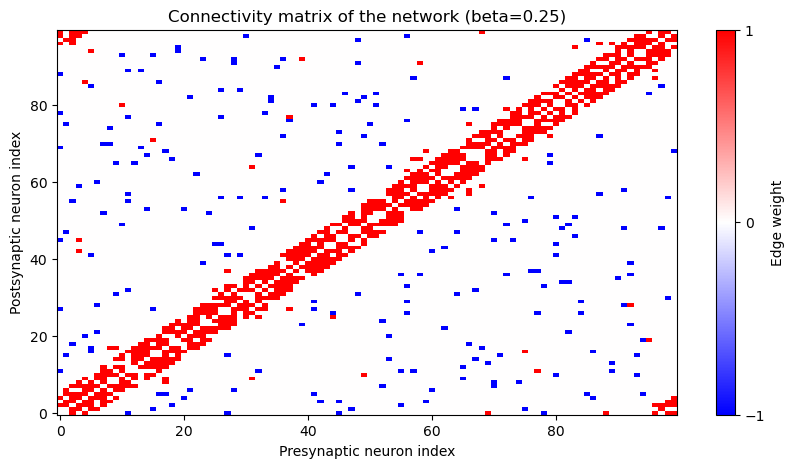

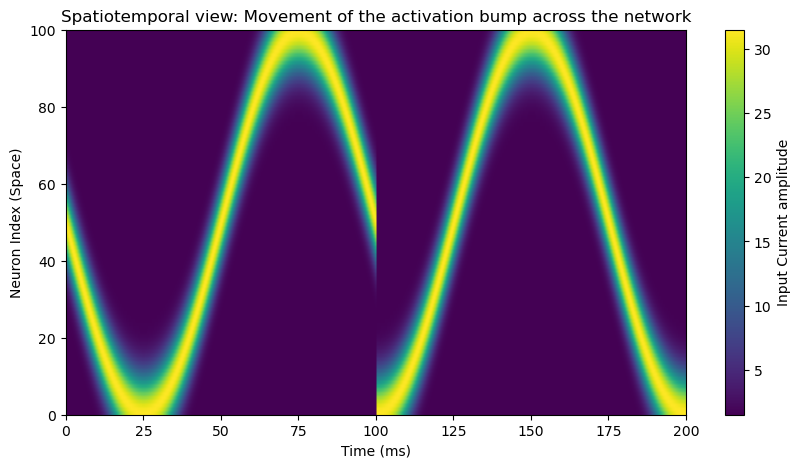

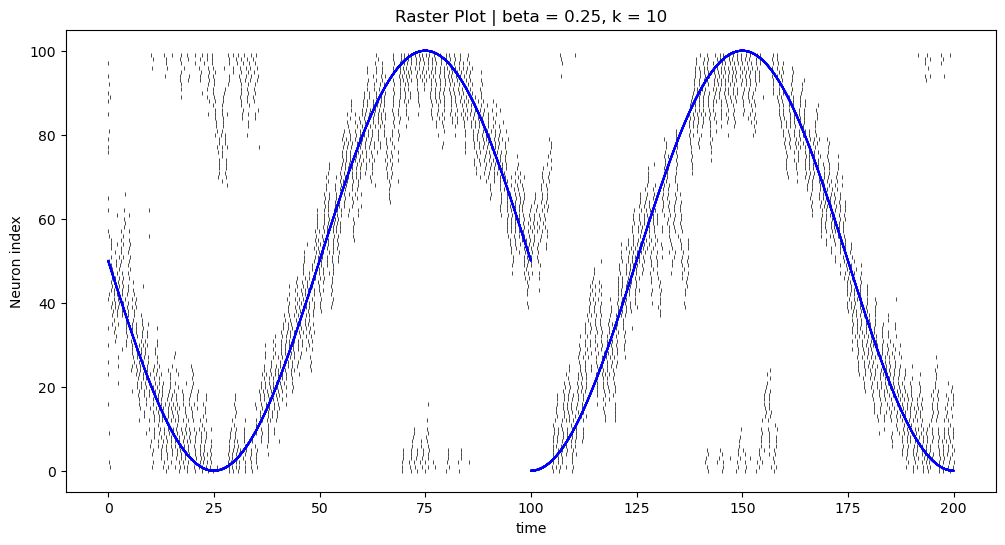

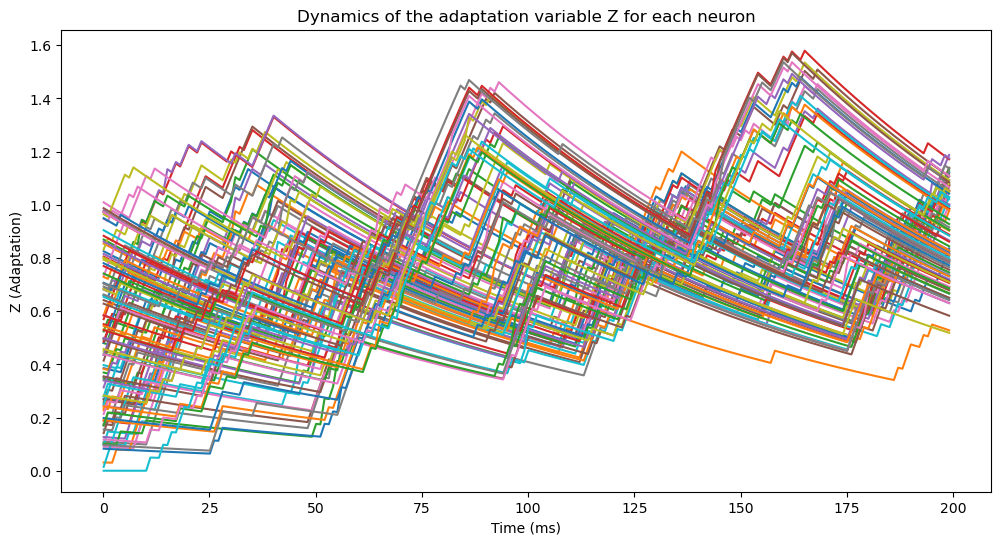

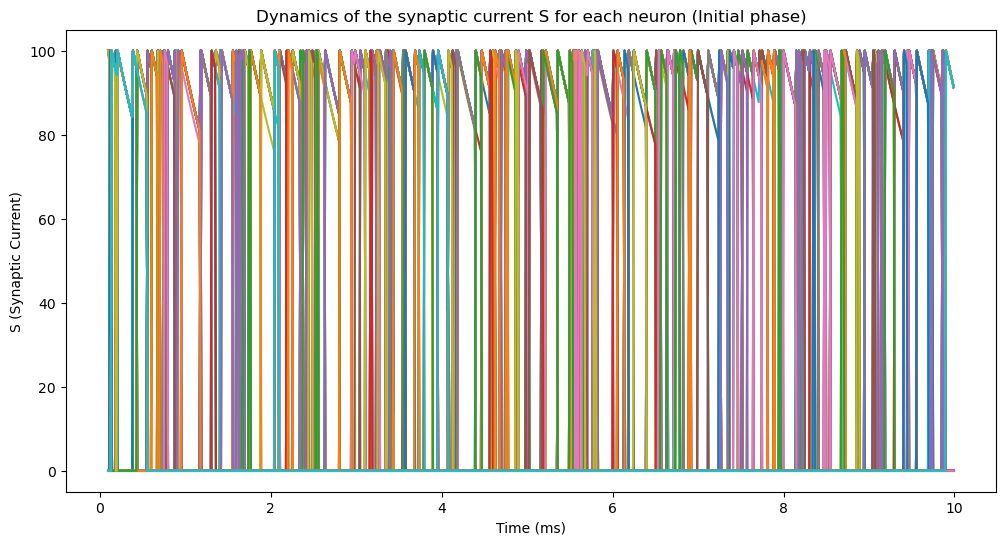

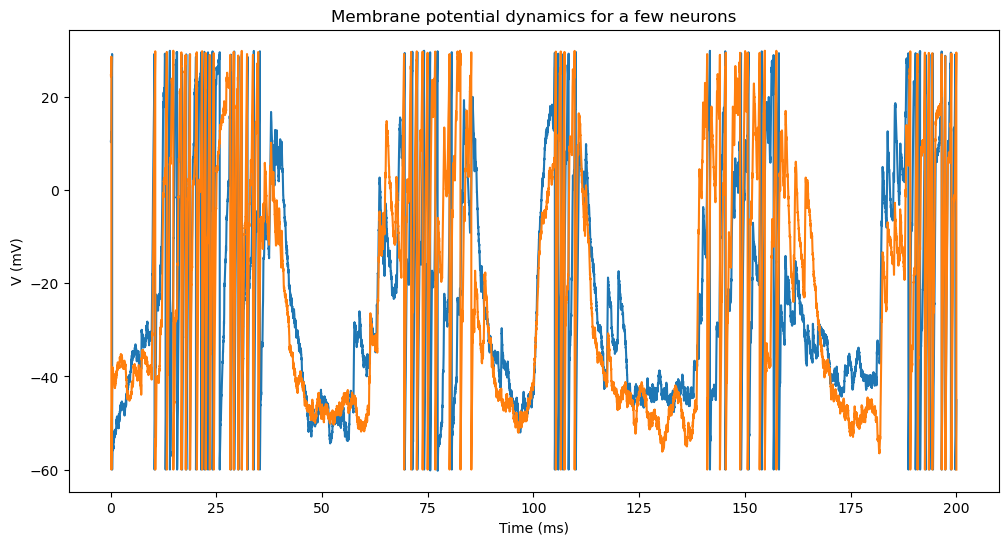

In [ ]:
# ================================================
# MAIN EXECUTION
# ================================================
# Modify `config` in Cell 2, then rerun only this cell.

spike_mon, state_mon, I_oscillatory_matrix, t_vec, time_steps, A, M, Wsyn_matrix, G_nx = run_simulation(config)

metrics = compute_metrics(spike_mon, config)
print(f"Active neurons : {metrics['active_neurons']} / {config['N']}")
print(f"Firing rates : {metrics['firing_rates']} Hz")
print(f"Mean firing rate : {metrics['mean_firing_rate']:.2f} Hz")
print(f"Std firing rate : {metrics['std_firing_rate']:.2f} Hz")
print(f"Synchrony index  : {metrics['synchrony_index']:.4f}")

plot_results(spike_mon, state_mon, A, M, I_oscillatory_matrix, t_vec, config)

In [ ]:
import itertools

# List of parameter values to test
beta_list = [0.25]
k_list = [1, 5, 10, 15, 25, 35]
# Loop through all parameter combinations
for beta, k in itertools.product(beta_list, k_list):
    # Pass beta and k into config (or directly into build_network/run_simulation)
    config["beta"] = beta
    config["k"] = k

    # 1. Run simulation
    spike_mon, state_mon, I_oscillatory_matrix, t_vec, time_steps, A, M, Wsyn_matrix, G_nx = run_simulation(config)

    # 2. Call your original, untouched function
    plot_raster(spike_mon, t_vec, config)

# Sweep

In [ ]:
# ================================================
# PARAMETRIC SWEEP (beta x k) 
# ================================================
# Each call to run_simulation() starts from a clean Brian2 state (internal start_scope).

from itertools import product
import pandas as pd

beta_values = [0.0, 0.1, 0.25, 0.5, 0.8, 1.0]
k_values = [4, 6, 10] 

results = []
for beta, k in product(beta_values, k_values):
    cfg = {**config, "beta": beta, "k": k}   # clean override, base config untouched
    spike_m, _, _, _, _, _, _, _, G_nx = run_simulation(cfg, verbose=False)

    m = compute_metrics(spike_m, cfg)
    isi_metrics = compute_isi_cv(spike_m, cfg)
    topo = compute_network_metrics(G_nx, cfg)

    results.append({
        "beta": beta, "k": k,
        "mean_firing_rate": m["mean_firing_rate"],
        "std_firing_rate": m["std_firing_rate"],
        "active_neurons": m["active_neurons"],
        "synchrony_index": m["synchrony_index"],
        **isi_metrics,  # Injects cv_mean, cv_std, cv2_mean, cv2_std
        **topo, # Injects C, L, omega
    })
    print(f"beta={beta:.2f}, k={k:2d}  ->  firing={m['mean_firing_rate']:6.1f} Hz,"
          f" sync={m['synchrony_index']:.3f}, CV={isi_metrics['cv_mean']:.3f},"
          f" CV2={isi_metrics['cv2_mean']:.3f},"
          f" C={topo['C']:.3f}, L={topo['L']:.3f}, omega={topo['omega']:.3f},"
          )

df = pd.DataFrame(results)
#df.to_csv("sweep_results.csv", index=False)
df


beta=0.00, k= 4  ->  firing= 193.8 Hz, sync=0.093, CV=2.310, CV2=0.590, C=0.500, L=12.879, omega=-0.722,
beta=0.00, k= 6  ->  firing= 191.0 Hz, sync=0.101, CV=2.183, CV2=0.616, C=0.600, L=8.758, omega=-0.686,
beta=0.00, k=10  ->  firing= 192.8 Hz, sync=0.087, CV=2.267, CV2=0.621, C=0.667, L=5.455, omega=-0.593,
beta=0.10, k= 4  ->  firing= 185.0 Hz, sync=0.111, CV=2.087, CV2=0.659, C=0.321, L=4.461, omega=-0.205,
beta=0.10, k= 6  ->  firing= 187.8 Hz, sync=0.104, CV=2.119, CV2=0.645, C=0.390, L=3.379, omega=-0.188,
beta=0.10, k=10  ->  firing= 173.6 Hz, sync=0.293, CV=2.239, CV2=0.613, C=0.444, L=2.578, omega=-0.137,
beta=0.25, k= 4  ->  firing= 191.8 Hz, sync=0.108, CV=1.795, CV2=0.689, C=0.232, L=4.093, omega=-0.139,
beta=0.25, k= 6  ->  firing= 191.9 Hz, sync=0.105, CV=1.972, CV2=0.658, C=0.273, L=3.078, omega=-0.112,
beta=0.25, k=10  ->  firing= 190.7 Hz, sync=0.099, CV=2.103, CV2=0.635, C=0.304, L=2.404, omega=-0.075,
beta=0.50, k= 4  ->  firing= 226.0 Hz, sync=0.152, CV=1.045, CV

,beta,k,mean_firing_rate,std_firing_rate,active_neurons,synchrony_index,cv_mean,cv_std,cv2_mean,cv2_std,C,L,omega
0,0.00,4,193.85,37.428966,100,0.092988,2.309535,0.282693,0.589615,0.088600,0.500000,12.878788,-0.722265
1,0.00,6,191.00,46.265538,100,0.100913,2.182552,0.257901,0.616015,0.119076,0.600000,8.757576,-0.686210
2,0.00,10,192.80,34.309765,100,0.086924,2.267080,0.332682,0.621187,0.109065,0.666667,5.454545,-0.592763
3,0.10,4,185.00,44.051107,100,0.111383,2.087425,0.285805,0.658945,0.120176,0.321333,4.461010,-0.204601
4,0.10,6,187.80,47.335610,100,0.104149,2.118622,0.239030,0.644918,0.115021,0.389683,3.378586,-0.187563
5,0.10,10,173.55,44.695050,100,0.293187,2.238910,0.322220,0.612920,0.130449,0.443730,2.577778,-0.136850
6,0.25,4,191.80,50.815942,100,0.107959,1.794716,0.252867,0.688583,0.101872,0.232238,4.092525,-0.138671
7,0.25,6,191.95,52.397018,100,0.104668,1.971672,0.225574,0.657998,0.110072,0.273222,3.078384,-0.112338
8,0.25,10,190.70,41.958432,100,0.099303,2.102932,0.283488,0.635457,0.094709,0.303870,2.404242,-0.074616
9,0.50,4,226.00,31.168895,100,0.151874,1.045084,0.280016,0.503802,0.074112,0.104810,3.564444,-0.023509


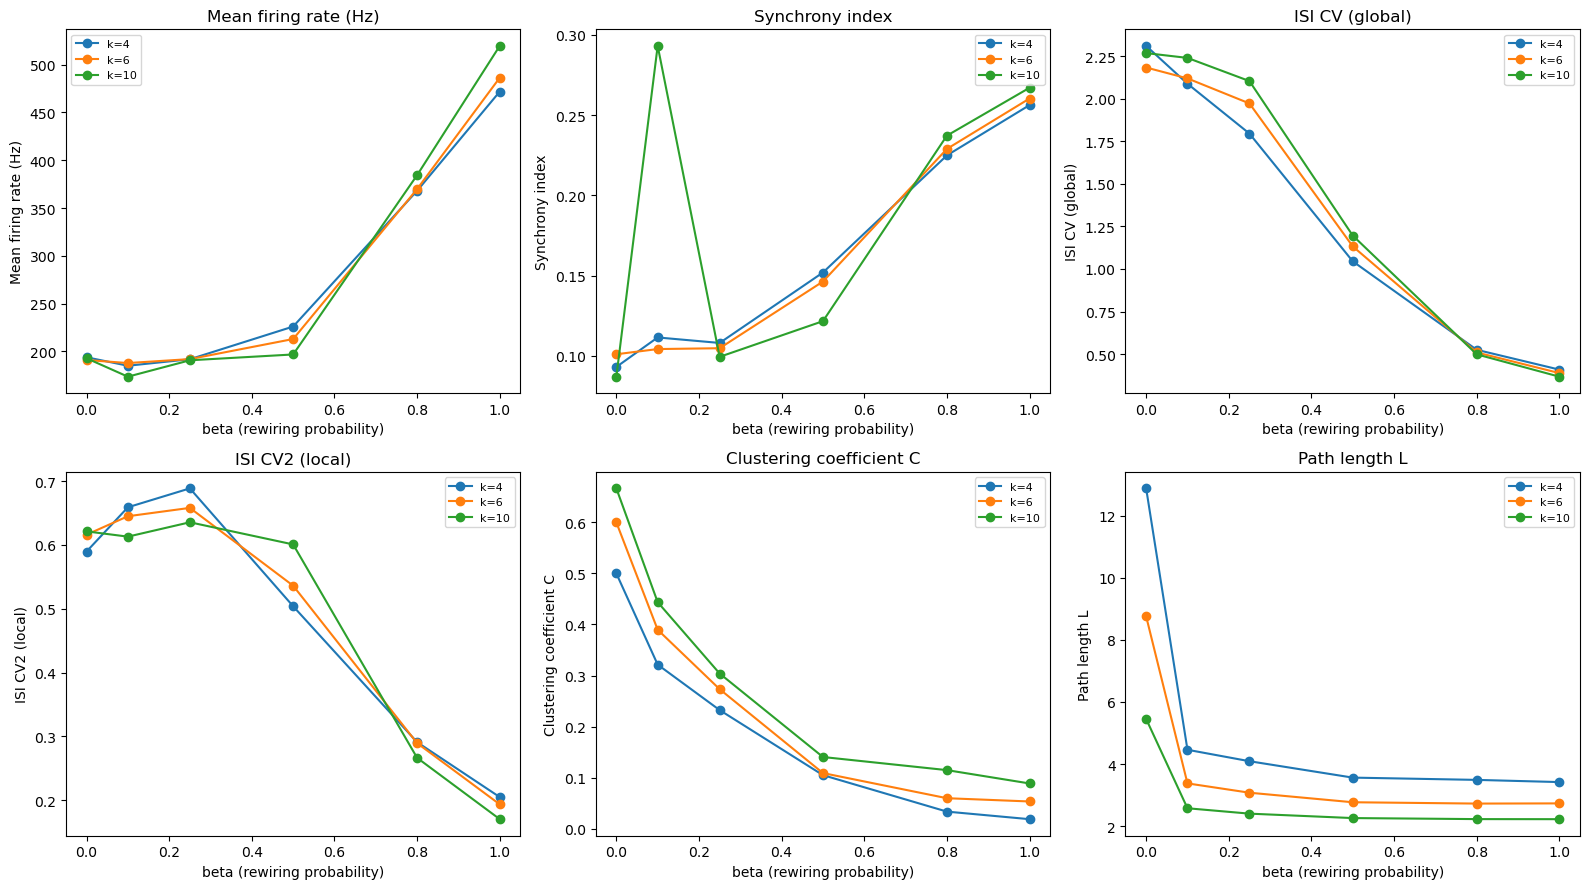

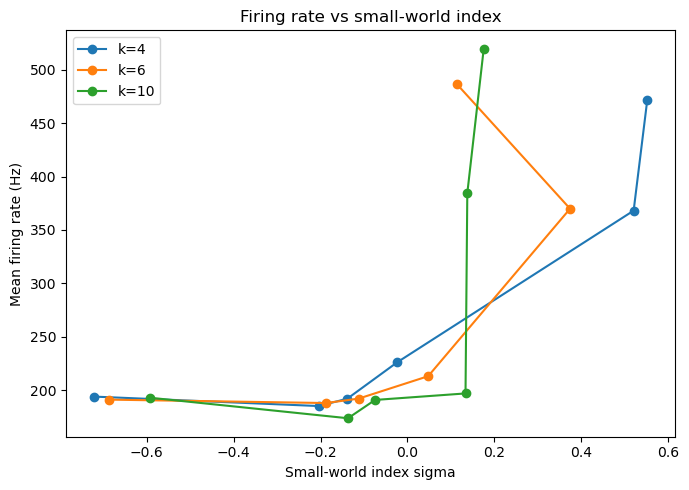

In [ ]:
# ================================================
# SWEEP PLOTS
# ================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sweep_metrics = [
    ("mean_firing_rate", "Mean firing rate (Hz)"),
    ("synchrony_index", "Synchrony index"),
    ("cv_mean", "ISI CV (global)"),
    ("cv2_mean", "ISI CV2 (local)"),
    ("C", "Clustering coefficient C"),
    ("L", "Path length L"),
    ("omega", "Small-world measure omega"),
]

for ax, (col, label) in zip(axes.flat, sweep_metrics):
    for k in sorted(df["k"].unique()):
        sub = df[df["k"] == k].sort_values("beta")
        ax.plot(sub["beta"], sub[col], marker="o", label=f"k={k}")
    ax.set_xlabel("beta (rewiring probability)")
    ax.set_ylabel(label)
    ax.set_title(label)
    if col == "omega":
        ax.axhline(0.0, color="gray", ls="--", lw=0.8)  # omega=0 small world 
    ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig("sweep_overview.png", dpi=130)
plt.show()

# Relation topology <-> dynamics
fig2, ax2 = plt.subplots(figsize=(7, 5))
for k in sorted(df["k"].unique()):
    sub = df[df["k"] == k].sort_values("beta")
    ax2.plot(sub["omega"], sub["mean_firing_rate"], marker="o", label=f"k={k}")
ax2.set_xlabel("Small-world index sigma")
ax2.set_ylabel("Mean firing rate (Hz)")
ax2.set_title("Firing rate vs small-world index")
ax2.legend()
plt.tight_layout()
#plt.savefig("firing_vs_sigma.png", dpi=130)
plt.show()
